# ATMS 523 Module 6 Homework
_Megan Walker-Radtke_

## Instructions
### Datasets

Use the Storm Prediction Center tornado dataset https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv

Also, use the ENSO, PDO, NAO, and AO dataframe from earlier module.

### Assignment

1) Aggregate the tornado data over the following states into a monthly count of tornadoes:
   
   - Illinois
   
2. Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

3. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.

4. Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.

5. Perform a feature importance and multipass permutation analysis of your features.

6. Create a SHAP Summary Plot showing feature importance and feature effects.

7. Create a SHAP Feature Dependence for the ENSO index.

8. Any observations on the importance of the various features in your model from the XAI techniques you tried?


#### Import Libraries and Datasets

In [ ]:
# Import libraries
import pandas as pd
import numpy as np




### Step 1: Aggregate the tornado data over the Illinois into a monthly count of tornadoes

In [33]:
# Import climate indices dataset (created in Module 4, saved as .csv, and imported here)
climate_indices = pd.read_csv('climate_indices.csv').iloc[:,:-1]  # Exclude the last column which is observed temp anomaly from Mod 4 (uncessary for this)
# Display the first few rows of the dataset
print(climate_indices.head())

# Import tornado dataset
tornado_data = pd.read_csv('1950-2021_actual_tornadoes.csv')
# Display the first few rows of the dataset
print(tornado_data.head())

   Unnamed: 0  ENSO   PDO   NAO     AO
0  1951-01-01   1.5 -1.19  0.08 -0.085
1  1951-02-01   0.9 -1.52  0.70 -0.400
2  1951-03-01  -0.1 -1.72 -1.02 -1.934
3  1951-04-01  -0.3 -1.35 -0.22 -0.776
4  1951-05-01  -0.7 -1.29 -0.59 -0.863
    om    yr  mo  dy        date      time  tz  st  stf  stn  ...   len  wid  \
0  192  1950  10   1  1950-10-01  21:00:00   3  OK   40   23  ...  15.8   10   
1  193  1950  10   9  1950-10-09  02:15:00   3  NC   37    9  ...   2.0  880   
2  195  1950  11  20  1950-11-20  02:20:00   3  KY   21    1  ...   0.1   10   
3  196  1950  11  20  1950-11-20  04:00:00   3  KY   21    2  ...   0.1   10   
4  197  1950  11  20  1950-11-20  07:30:00   3  MS   28   14  ...   2.0   37   

   ns  sn  sg   f1  f2  f3  f4  fc  
0   1   1   1   25   0   0   0   0  
1   1   1   1   47   0   0   0   0  
2   1   1   1  177   0   0   0   0  
3   1   1   1  209   0   0   0   0  
4   1   1   1  101   0   0   0   0  

[5 rows x 29 columns]


In [34]:
# Clean up climate_indices dataframe - need to rename and set date as index
climate_indices.rename(columns={'Unnamed: 0': 'date'}, inplace=True)
climate_indices.set_index(pd.to_datetime(climate_indices['date']), inplace=True)
climate_indices.drop(columns=['date'], inplace=True)
climate_indices.head()


,ENSO,PDO,NAO,AO
date,,,,
1951-01-01,1.5,-1.19,0.08,-0.085
1951-02-01,0.9,-1.52,0.70,-0.400
1951-03-01,-0.1,-1.72,-1.02,-1.934
1951-04-01,-0.3,-1.35,-0.22,-0.776
1951-05-01,-0.7,-1.29,-0.59,-0.863


In [35]:
# Check the data type of the 'date' column
type(tornado_data['date'].iat[0])
# stored as a string, so need to convert it to a datetime object in order to use datetime functions for aggregation
tornado_data['date'] = pd.to_datetime(tornado_data['date'], errors='coerce')
# check parse failures
print("Check NaNs:", tornado_data['date'].isna().sum())
# verify dtype
print("Date dtype:", tornado_data['date'].dtype)
# 'date' converted to datetime with no errors resulting in NaNs



Check NaNs: 0
Date dtype: datetime64[ns]


In [36]:
# Take only the subset of tornadoes from Illinois
tornado_IL = tornado_data[tornado_data['st'] == 'IL'].copy()
tornado_IL.set_index('date', inplace=True)
tornado_IL.head(20)

,om,yr,mo,dy,time,tz,st,stf,stn,mag,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
date,,,,,,,,,,,,,,,,,,,,,
1950-12-02,198,1950,12,2,15:00:00,3,IL,17,7,2,...,18.8,50,1,1,1,119,117,0,0,0
1950-12-02,199,1950,12,2,16:00:00,3,IL,17,8,3,...,18.0,200,1,1,1,119,5,0,0,0
1950-12-02,201,1950,12,2,17:30:00,3,IL,17,9,1,...,9.6,50,1,1,1,157,0,0,0,0
1950-01-25,6,1950,1,25,21:00:00,3,IL,17,3,2,...,0.1,100,1,1,1,91,0,0,0,0
1950-01-03,2,1950,1,3,11:55:00,3,IL,17,2,3,...,3.6,130,1,1,1,135,0,0,0,0
1950-03-27,48,1950,3,27,16:30:00,3,IL,17,4,2,...,3.0,50,1,1,1,113,0,0,0,0
1950-06-13,135,1950,6,13,03:00:00,3,IL,17,5,1,...,0.1,10,1,1,1,15,0,0,0,0
1950-07-16,165,1950,7,16,22:15:00,3,IL,17,6,1,...,1.0,33,1,1,1,105,0,0,0,0
1951-11-13,241,1951,11,13,13:15:00,3,IL,17,3,2,...,47.4,50,1,1,1,125,179,113,0,0


In [37]:
# Aggregate to monthly counts and manually check for accuracy over the first 12 months
tornado_IL_monthly = tornado_IL.resample('M').size()
tornado_IL_monthly.head(12)
# Looks good!

/var/folders/jc/711xkp256bz0pq8mq4dcp94h0000gn/T/ipykernel_25574/3785086535.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tornado_IL_monthly = tornado_IL.resample('M').size()


date
1950-01-31    2
1950-02-28    0
1950-03-31    1
1950-04-30    0
1950-05-31    0
1950-06-30    1
1950-07-31    1
1950-08-31    0
1950-09-30    0
1950-10-31    0
1950-11-30    0
1950-12-31    3
Freq: ME, dtype: int64

In [38]:
# The climate indices dataset is monthly, but the index is set to the first day of the month,
# whereas the tornado_IL_monthly index is set to the last day of the month.
# So, we need to adjust the tornado data index to match the climate indices index for merging
tornado_IL_monthly.index = tornado_IL_monthly.index - pd.offsets.MonthBegin(1)  # Set to first day of month
tornado_IL_monthly.head(12)

date
1950-01-01    2
1950-02-01    0
1950-03-01    1
1950-04-01    0
1950-05-01    0
1950-06-01    1
1950-07-01    1
1950-08-01    0
1950-09-01    0
1950-10-01    0
1950-11-01    0
1950-12-01    3
dtype: int64

### Step 2: Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [42]:
# the tornado and climate indices datasets now have aligned monthly indices and can be merged for analysis
# Combine the two datasets into a single DataFrame for analysis
combined_data = pd.merge(climate_indices, tornado_IL_monthly.rename('IL_tornado_count'), left_index=True, right_index=True, how='inner')
combined_data.head(-10)

,ENSO,PDO,NAO,AO,IL_tornado_count
date,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0
1951-02-01,0.9,-1.52,0.70,-0.400,0
1951-03-01,-0.1,-1.72,-1.02,-1.934,0
1951-04-01,-0.3,-1.35,-0.22,-0.776,0
1951-05-01,-0.7,-1.29,-0.59,-0.863,0
...,...,...,...,...,...
2020-10-01,0.5,-0.62,-0.65,-0.072,0
2020-11-01,0.7,-1.58,2.54,2.086,8
2020-12-01,1.8,-0.99,-0.30,-1.736,0


### Step 3: Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.

In [43]:
# Import libraries for modeling
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, VBox, HBox, fixed, Output
from IPython.display import display, HTML

In [ ]:
# Set variables for modeling
df = combined_data.copy(deep=True)
target_col = 'IL_tornado_count'
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()
feature_names = X.columns.tolist()
X.shape, y.shape

((852, 4), (852,))

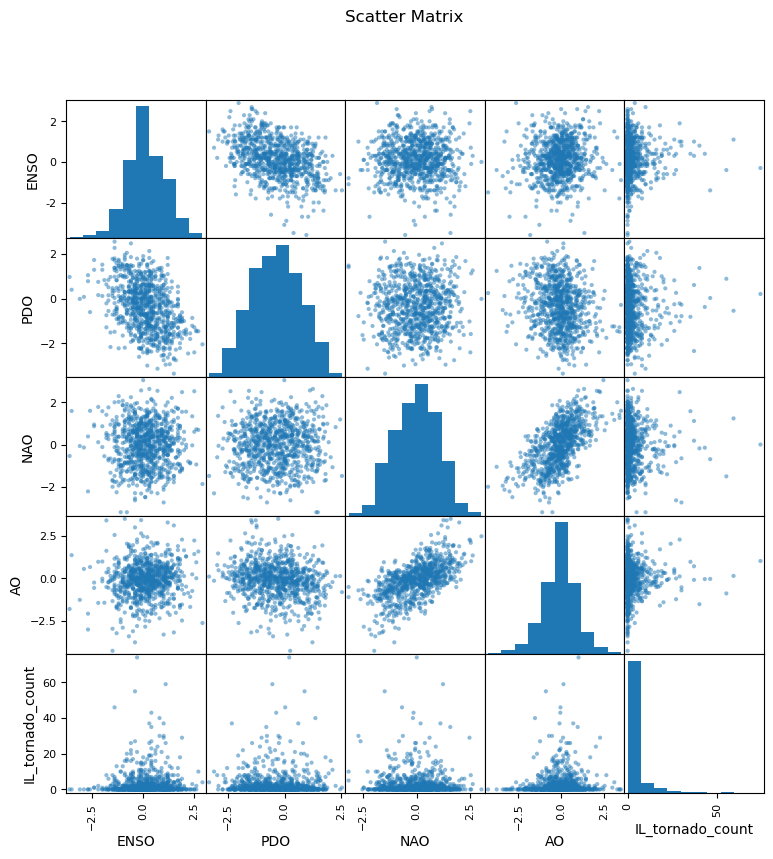

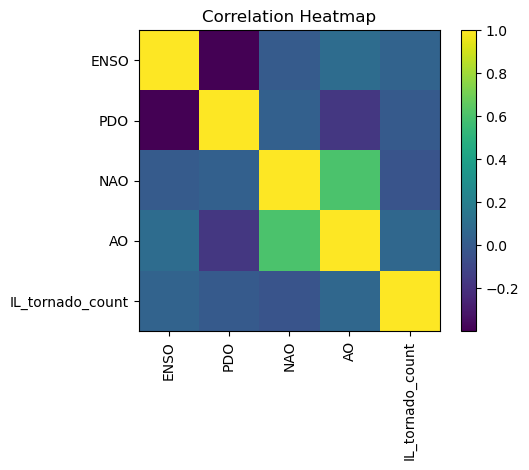

In [ ]:
# EDA visualization 
sample = X.copy()
sample[target_col] = y

scatter_matrix(sample, figsize=(9,9), diagonal='hist')
plt.suptitle('Scatter Matrix')
plt.show()

corr = df.corr(numeric_only=True)
fig, ax = plt.subplots()
im = ax.imshow(corr.values, interpolation='nearest')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
ax.set_title('Correlation Heatmap')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# There appear to be some correlations between some of the individual climate indices and tornado counts, but the data are NOISY, and the correlation coefficients are low.

In [ ]:
# Split the training and testing data
# reserving 25% of the data for testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (639, 4) Test size: (213, 4)


RMSE: 2.84
RMSE as fraction of observed std dev: 0.36
Correlation Coefficient: 0.09


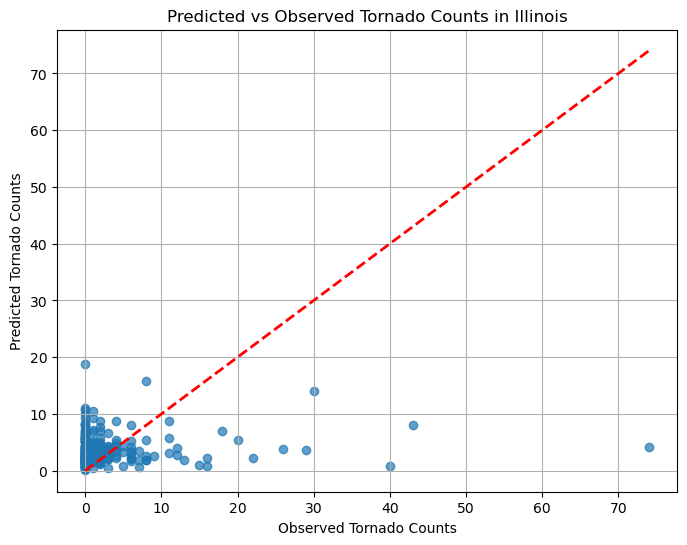

In [ ]:
# Fit the random forest regression model
forest = RandomForestRegressor(n_estimators=1000, random_state=42)
forest.fit(X_train, y_train)

# Use the model to make predictions on the test set
y_pred = forest.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(root_mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')
# RMSE as a fraction of the standard deviation of the observed values
rmse_frac = rmse / np.std(y_test)
print(f'RMSE as fraction of observed std dev: {rmse_frac:.2f}')
corr_coef = np.corrcoef(y_test, y_pred)[0, 1]
print(f'Correlation Coefficient: {corr_coef:.2f}')

# Plot predicted vs observed tornado counts
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Observed Tornado Counts')
plt.ylabel('Predicted Tornado Counts')
plt.title('Predicted vs Observed Tornado Counts in Illinois')
plt.grid()
plt.show()

# Just about as terrible as you can get: all scatter, no skill.  
# The climate indices alone do not appear to provide useful predictive information for monthly tornado counts in Illinois.




### Step 4: Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.


In [57]:
df

,ENSO,PDO,NAO,AO,IL_tornado_count
date,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0
1951-02-01,0.9,-1.52,0.70,-0.400,0
1951-03-01,-0.1,-1.72,-1.02,-1.934,0
1951-04-01,-0.3,-1.35,-0.22,-0.776,0
1951-05-01,-0.7,-1.29,-0.59,-0.863,0
...,...,...,...,...,...
2021-08-01,0.6,-0.95,-0.28,-0.209,16
2021-09-01,0.8,-1.96,-0.21,-0.252,0
2021-10-01,0.7,-3.13,-2.29,-0.146,10


In [58]:
# Import additional libraries for one-hot encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# create month column 
df['month'] = df.index.month

# add one-hot encoding for month
month_dummies = pd.get_dummies(df['month'], prefix='month')
df = df.join(month_dummies)
df.head(20)

,ENSO,PDO,NAO,AO,IL_tornado_count,month,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0,1,True,False,False,False,False,False,False,False,False,False,False,False
1951-02-01,0.9,-1.52,0.70,-0.400,0,2,False,True,False,False,False,False,False,False,False,False,False,False
1951-03-01,-0.1,-1.72,-1.02,-1.934,0,3,False,False,True,False,False,False,False,False,False,False,False,False
1951-04-01,-0.3,-1.35,-0.22,-0.776,0,4,False,False,False,True,False,False,False,False,False,False,False,False
1951-05-01,-0.7,-1.29,-0.59,-0.863,0,5,False,False,False,False,True,False,False,False,False,False,False,False
1951-06-01,0.2,-1.77,-1.64,-0.918,2,6,False,False,False,False,False,True,False,False,False,False,False,False
1951-07-01,-1.0,-0.23,1.37,0.090,0,7,False,False,False,False,False,False,True,False,False,False,False,False
1951-08-01,-0.2,-1.76,-0.22,-0.377,0,8,False,False,False,False,False,False,False,True,False,False,False,False
1951-09-01,-1.1,-0.78,-1.36,-0.818,0,9,False,False,False,False,False,False,False,False,True,False,False,False


RMSE: 2.85
RMSE as fraction of observed std dev: 0.34
Correlation Coefficient: 0.28


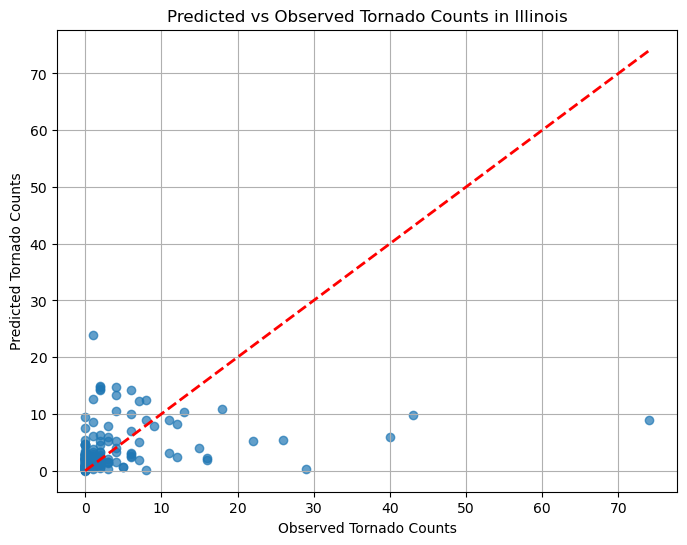

In [ ]:
# Try random forest model again, this time with one-hot encoded month features included
X = df.drop(columns=['IL_tornado_count'])
y = df['IL_tornado_count']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the random forest regression model
forest = RandomForestRegressor(n_estimators=1000, random_state=42)
forest.fit(X_train, y_train)

# Use the model to make predictions on the test set
y_pred = forest.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(root_mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')
# RMSE as a fraction of the standard deviation of the observed values
rmse_frac = rmse / np.std(y_test)
print(f'RMSE as fraction of observed std dev: {rmse_frac:.2f}')
corr_coef = np.corrcoef(y_test, y_pred)[0, 1]
print(f'Correlation Coefficient: {corr_coef:.2f}')

# Plot predicted vs observed tornado counts
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Observed Tornado Counts')
plt.ylabel('Predicted Tornado Counts')
plt.title('Predicted vs Observed Tornado Counts in Illinois')
plt.grid()
plt.show()

# Still terrible! Although the correlation coefficient improved a bit, RMSE is basically unchanged.